In [2]:
from sklearn import datasets
#导入K均值算法对象 是一个类,后面可以创建这个类
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

In [4]:
iris = datasets.load_iris()
X = iris.data[:,:2]

In [14]:
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)
rgb = [[255,238,255],
       [219,238,244],
       [228,228,228]]
rgb = np.array(rgb)/255.
cmap_light = ListedColormap(rgb)

In [72]:
#聚类
#指定有三个簇
kmeans = KMeans(n_clusters = 3,n_init = 'auto')
#拟合数据并预测数电所属的簇标签
#预测后有新的分组,并没有像之前那样引入原数据标签,这里我们自己预测然后标记原数据并分组
#每一次同一位置的0,1,2标记可能不同,同一位置的分组相同
cluster_labels = kmeans.fit(X).predict(X)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [24]:
#聚类预测
Z = kmeans.predict(np.c_[xx1.ravel(),xx2.ravel()])
Z = Z.reshape(xx1.shape)

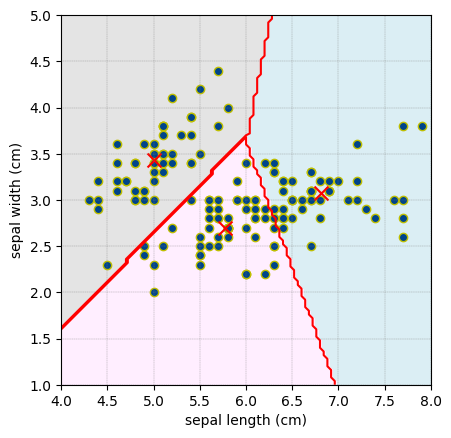

In [118]:
fig,ax = plt.subplots()

ax.contourf(xx1,xx2,Z,cmap = cmap_light)
ax.scatter(x=X[:,0],y = X[:,1],
           color = np.array([0,68,138])/255.,
           alpha = 1.0,
           linewidth = 1,edgecolor = 'y')
#绘制决策边界
#unique找出不重复唯一值,tolist转换成python自带列表
levels = np.unique(Z).tolist()
ax.contour(xx1,xx2,Z,levels = levels,colors='r')
#获取质心坐标
#每一行是一个坐标点
centroids = kmeans.cluster_centers_
#提取列就是x和y分开
ax.scatter(centroids[:,0],centroids[:,1],
           marker = 'x',s=100,linewidth = 1.5,
           color = 'r')

ax.set_xlim(4,8);ax.set_ylim(1,5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle = '--',linewidth = 0.25,
        color = [0.5,0.5,0.5])
ax.set_aspect('equal',adjustable = 'box')